In [69]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'income_tax_collection',
    persist_directory = './income_tax_collection'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [70]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

graph_builder = StateGraph(AgentState)

In [71]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [72]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [73]:
from langchain import hub

generate_prompt = hub.pull("rlm/rag-prompt")

def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

/home/swjeong/langchain/langgraph/.venv/lib/python3.13/site-packages/langsmith/client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [74]:
from langchain import hub
from typing import Literal 
doc_relevance_doc_prompt = hub.pull("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['generate','rewrite']:
    query = state['query']
    context = state['context']
    print(f'context == {context}')
    doc_relevance_chain = doc_relevance_doc_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})
    print(f'doc relevance response: {response}')
    if response['Score'] == 1:
        return 'generate'
    
    return 'rewrite'

/home/swjeong/langchain/langgraph/.venv/lib/python3.13/site-packages/langsmith/client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [75]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(f"""
사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요
사전: {dictionary}
질문: {{query}}
""")

def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    response = rewrite_chain.invoke({'query': query})
    return {'query': response}

In [76]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

In [77]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges('retrieve', check_doc_relevance)
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)

In [78]:
graph = graph_builder.compile()

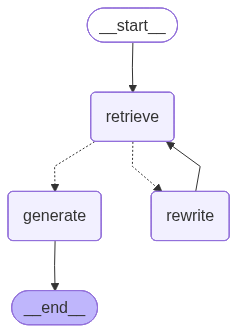

In [79]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [80]:
initial_state = {'query': '연봉 5천만원 세금'}
graph.invoke(initial_state)

context == [Document(metadata={'source': './documents/income_tax.txt'}, page_content='근속연수에 따라 정한 다음의 금액\n\n| 근속연수      | 공제액                  |\n|----------------|--------------------------|\n| 5년 이하       | 100만원×근속연수       |\n| 5년 초과 10년 이하 | 500만원+200만원×(근속연수-5) |\n| 10년 초과 20년 이하 | 1천500만원+250만원×(근속연수-10) |\n| 20년 초과     | 4천만원+300만원×(근속연수-20) |\n\n환산급여에 따라 정한 다음의 금액'), Document(metadata={'source': './documents/income_tax.txt'}, page_content='3주택 이상을 소유하고 해와 주택의 보증금의 합계액이 3억을 초과하는 경우\n\n\n주택(해당 과세기간의 기준시가가 12억 이하인 주택수에 포함하나, 주택은 소유하고 해당 주택의 보증금의 합계액이 3억 이상인 금액으로서 대폭발라정으로 정하는 금액을 초과하는 경우'), Document(metadata={'source': './documents/income_tax.txt'}, page_content='‘공신입법’에 따른 공익신탁의 의익\n    가. 세호소득 중 다음 각 목의 이내 하나에 해당하는 소득\n        나. 1가의 주택을 소유하는 자의 주택매매소득(제93조에 따른 기준시가가 1억원을 초과하는 주택 및 국외에 소재하는 주택의 매도소득은 과세된다) 또는 해당 소득세기한에 대통령령이 정하는 송수입금액에 합계하여 2천만원 이하의 자가 주택매매소득(2018년 12월 31일 이전에 발생한 과세기간까지 발생하는 소득으로 한정한다).\n        다. 대통령령으로 정하는 승안세 발생하는 소득\n        라. 정당기간 5년 이상의 임치(摳治)의 임금(蜍

TypeError: BaseModel.__init__() takes 1 positional argument but 2 were given